<a href="https://colab.research.google.com/github/VSUrhuel/forage-classifications/blob/main/Progressive_MobileNetV3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import layers, models, optimizers, regularizers, callbacks
from tensorflow.keras.applications import MobileNetV3Large # or MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
BASE_DIR = '/content/drive/MyDrive/Undergrad Thesis/Dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
SAVE_PATH = '/content/drive/MyDrive/Undergrad Thesis/Dataset/Models/mobilenetv3_progressive.keras'

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 14

In [5]:
print("Setting up Generators with MobileNetV3 Preprocessing...")

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=[0.9, 1.1],
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='reflect'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

Setting up Generators with MobileNetV3 Preprocessing...


In [6]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3577 images belonging to 14 classes.
Found 763 images belonging to 14 classes.


In [7]:
print("\nComputing Class Weights...")
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))
print(f"Weights: {class_weights_dict}")


Computing Class Weights...
Weights: {0: np.float64(0.998046875), 1: np.float64(1.0780590717299579), 2: np.float64(0.9324817518248175), 3: np.float64(1.0179282868525896), 4: np.float64(0.9569288389513109), 5: np.float64(0.9462962962962963), 6: np.float64(1.0735294117647058), 7: np.float64(1.0557851239669422), 8: np.float64(1.0179282868525896), 9: np.float64(0.9533582089552238), 10: np.float64(0.9428044280442804), 11: np.float64(1.0872340425531914), 12: np.float64(1.0179282868525896), 13: np.float64(0.9605263157894737)}


In [8]:
# --- 3. BUILD MODEL WITH "PYRAMID HEAD" ---
# The Kaggle notebook uses multiple Dense -> BN -> Dropout blocks.
# We adapt this for MobileNetV3.
print("\nBuilding Model...")

base_model = MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False # Freeze the base model

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

# Block 1 (High Capacity)
x = layers.Dense(512)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('swish')(x)
x = layers.Dropout(0.3)(x)

# Block 2 (Medium Capacity)
x = layers.Dense(256)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('swish')(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)


Building Model...


In [15]:
# HELPER UNFREEZE FUNCTION
def unfreeze_layers(num_layers_to_unfreeze):
    """
    Unfreezes the top N layers of the GLOBAL base_model.
    """
    # 1. Unlock the backbone generally
    base_model.trainable = True

    # 2. Re-freeze EVERYTHING inside it first
    for layer in base_model.layers:
        layer.trainable = False

    # 3. Unfreeze only the specific last N layers (Excluding Batch Norm)
    #    We count backwards from the end
    unfrozen_count = 0
    for layer in base_model.layers[-num_layers_to_unfreeze:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True
            unfrozen_count += 1

    print(f"\nSTATUS: Unfrozen top {num_layers_to_unfreeze} backbone layers (Actual trainable layers: {unfrozen_count}).")
    print(f"        (Batch Normalization layers kept frozen for stability)")

In [10]:
# Round 1: Training Head Only
print("\n========== ROUND 1: Training Head (10 Epochs) ==========")
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3), # High LR for head
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_r1 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights_dict
)


========== ROUND 1: Training Head (10 Epochs) ==========


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3429s 30s/step - accuracy: 0.5860 - loss: 1.2593 - val_accuracy: 0.8231 - val_loss: 0.5323
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 56s 499ms/step - accuracy: 0.8539 - loss: 0.4420 - val_accuracy: 0.8834 - val_loss: 0.3813
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 56s 500ms/step - accuracy: 0.8762 - loss: 0.3622 - val_accuracy: 0.8886 - val_loss: 0.3325
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 494ms/step - accuracy: 0.9020 - loss: 0.3111 - val_accuracy: 0.8847 - val_loss: 0.3669
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 491ms/step - accuracy: 0.9006 - loss: 0.2856 - val_accuracy: 0.8965 - val_loss: 0.3315
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 490ms/step - accuracy: 0.9101 - loss: 0.2560 - val_accuracy: 0.9030 - val_loss: 0.2847
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 492ms/step - accuracy: 0.9219 - loss: 0.2137 - val_accuracy: 0.8991 - val_loss: 0.2921
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 56s 495ms/step - accuracy: 0.9319 - loss: 0

In [17]:
# --- ROUND 2: UNFREEZE TOP 40 LAYERS ---
print("\n========== ROUND 2: Unfreeze Top 40 (10 Epochs) ==========")
unfreeze_layers(40)

model.compile(
    optimizer=optimizers.Adam(learning_rate=2e-4), # LR scaled by 0.2 (Kaggle Logic)
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_r2 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights_dict
)


========== ROUND 2: Unfreeze Top 40 (10 Epochs) ==========

STATUS: Unfrozen top 40 backbone layers (Actual trainable layers: 32).
        (Batch Normalization layers kept frozen for stability)
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 98s 696ms/step - accuracy: 0.9349 - loss: 0.1864 - val_accuracy: 0.9358 - val_loss: 0.2181
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 494ms/step - accuracy: 0.9588 - loss: 0.1214 - val_accuracy: 0.9056 - val_loss: 0.3048
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 490ms/step - accuracy: 0.9581 - loss: 0.1129 - val_accuracy: 0.9476 - val_loss: 0.1689
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 492ms/step - accuracy: 0.9756 - loss: 0.0745 - val_accuracy: 0.9227 - val_loss: 0.2258
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 491ms/step - accuracy: 0.9794 - loss: 0.0675 - val_accuracy: 0.9371 - val_loss: 0.2086
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 490ms/step - accuracy: 0.9869 - loss: 0.0421 - val_accuracy: 0.9581 - val_loss: 0.1252
Epoch 7/10
112/112 

In [22]:
print("\n========== ROUND 3: Unfreeze Top 80 (20 Epochs) ==========")
unfreeze_layers(80)

# Add Early Stopping here since this is the final fine-tuning
es = callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
mc = callbacks.ModelCheckpoint(SAVE_PATH, save_best_only=True, monitor='val_accuracy')

model.compile(
    optimizer=optimizers.Adam(learning_rate=4e-5), # LR scaled by 0.2 again
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_r3 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights_dict,
    callbacks=[es, mc]
)

print("Training Complete. Model saved.")


========== ROUND 3: Unfreeze Top 80 (20 Epochs) ==========

STATUS: Unfrozen top 80 backbone layers (Actual trainable layers: 63).
        (Batch Normalization layers kept frozen for stability)
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 106s 729ms/step - accuracy: 0.9951 - loss: 0.0178 - val_accuracy: 0.9712 - val_loss: 0.0990
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 57s 504ms/step - accuracy: 0.9968 - loss: 0.0146 - val_accuracy: 0.9712 - val_loss: 0.0968
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 495ms/step - accuracy: 0.9959 - loss: 0.0176 - val_accuracy: 0.9672 - val_loss: 0.0965
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 56s 498ms/step - accuracy: 0.9960 - loss: 0.0157 - val_accuracy: 0.9685 - val_loss: 0.1004
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 56s 501ms/step - accuracy: 0.9959 - loss: 0.0125 - val_accuracy: 0.9672 - val_loss: 0.1045
Training Complete. Model saved.


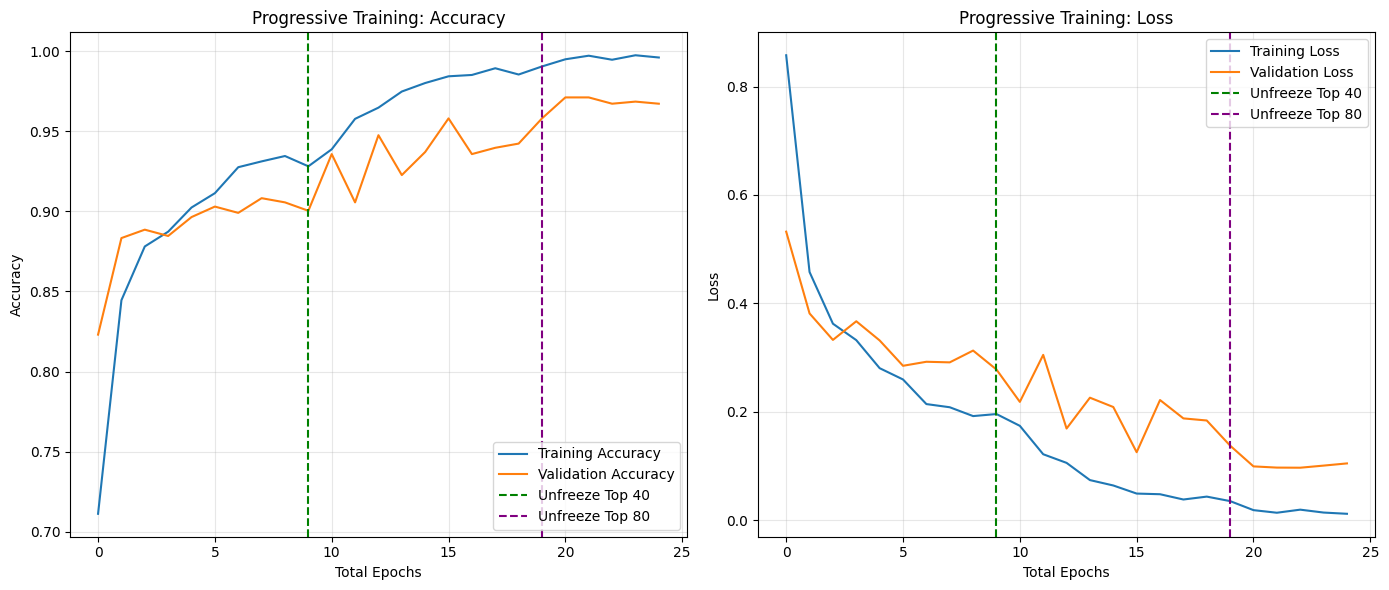

In [24]:
import matplotlib.pyplot as plt

def plot_progressive_history(h1, h2, h3):
    # 1. Concatenate the history dictionaries
    acc = h1.history['accuracy'] + h2.history['accuracy'] + h3.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy'] + h3.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss'] + h3.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss'] + h3.history['val_loss']

    epochs_range = range(len(acc))

    # Calculate transition points (where rounds end)
    round1_end = len(h1.history['accuracy']) - 1
    round2_end = round1_end + len(h2.history['accuracy'])

    plt.figure(figsize=(14, 6))

    # --- PLOT ACCURACY ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')

    # Add vertical lines for transitions
    plt.axvline(x=round1_end, color='green', linestyle='--', label='Unfreeze Top 40')
    plt.axvline(x=round2_end, color='purple', linestyle='--', label='Unfreeze Top 80')

    plt.legend(loc='lower right')
    plt.title('Progressive Training: Accuracy')
    plt.xlabel('Total Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)

    # --- PLOT LOSS ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')

    # Add vertical lines for transitions
    plt.axvline(x=round1_end, color='green', linestyle='--', label='Unfreeze Top 40')
    plt.axvline(x=round2_end, color='purple', linestyle='--', label='Unfreeze Top 80')

    plt.legend(loc='upper right')
    plt.title('Progressive Training: Loss')
    plt.xlabel('Total Epochs')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run it
plot_progressive_history(history_r1, history_r2, history_r3)